# **Results Comparison**

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
folder_path = 'model_metrics'    

In [11]:
def open_json(folder_path):
    all_data = []
    for file in os.listdir(folder_path):
        if file.endswith('.json'):
            with open(os.path.join(folder_path, file), 'r') as f:
                data = json.load(f)
                all_data.append(data)
    
    return all_data

metrics = open_json(folder_path)
print(metrics)


[{'model': 'NN', 'configuration': 'Configuration 1', 'accuracy': 0.7724867724867724, 'precision': 0.7389830508474576, 'recall': 0.6964856230031949, 'f1_score': 0.7171052631578947, 'auc': 0.7613353729248047, 'timestamp': '2026-03-11 09:16:37'}, {'model': 'NN', 'configuration': 'Configuration 2', 'accuracy': 0.7804232804232805, 'precision': 0.7508532423208191, 'recall': 0.7028753993610224, 'f1_score': 0.7260726072607261, 'auc': 0.7690449357032776, 'timestamp': '2026-03-11 09:18:28'}, {'model': 'NN', 'configuration': 'Configuration 3', 'accuracy': 0.7552910052910053, 'precision': 0.7077922077922078, 'recall': 0.6964856230031949, 'f1_score': 0.7020933977455717, 'auc': 0.7466626763343811, 'timestamp': '2026-03-11 09:18:56'}]


In [12]:
df = pd.DataFrame(metrics)

In [13]:
df.head()

,model,configuration,accuracy,precision,recall,f1_score,auc,timestamp
0,NN,Configuration 1,0.772487,0.738983,0.696486,0.717105,0.761335,2026-03-11 09:16:37
1,NN,Configuration 2,0.780423,0.750853,0.702875,0.726073,0.769045,2026-03-11 09:18:28
2,NN,Configuration 3,0.755291,0.707792,0.696486,0.702093,0.746663,2026-03-11 09:18:56


Comparison Graphs

In [14]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score", "auc"]

df_long = df.melt(
    id_vars="configuration",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="value"
)

print(df_long.head())

     configuration     metric     value
0  Configuration 1   accuracy  0.772487
1  Configuration 2   accuracy  0.780423
2  Configuration 3   accuracy  0.755291
3  Configuration 1  precision  0.738983
4  Configuration 2  precision  0.750853


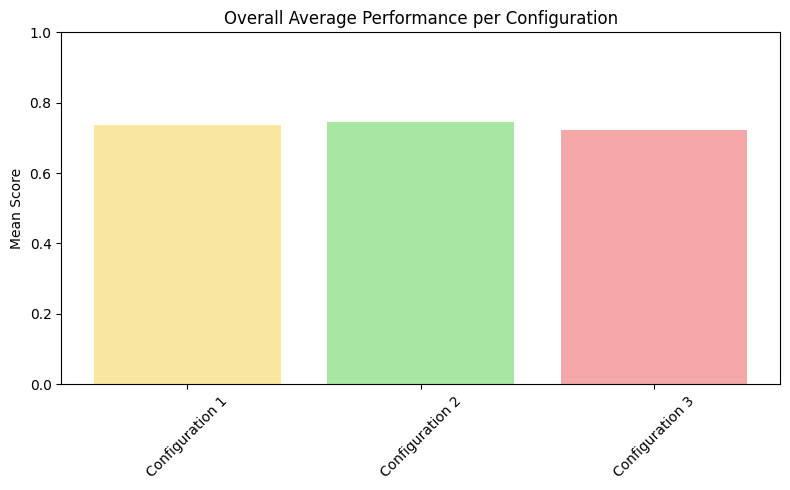

In [15]:

# Compute mean score
df["mean_score"] = df[["accuracy","precision","recall","f1_score","auc"]].mean(axis=1)

# Identify max and min
max_value = df["mean_score"].max()
min_value = df["mean_score"].min()

# Pastel color palette
pastel_green = "#A8E6A3"
pastel_red = "#F4A7A7"
pastel_yellow = "#F9E79F"

# Assign colors
colors = []

for value in df["mean_score"]:
    if value == max_value:
        colors.append(pastel_green)
    elif value == min_value:
        colors.append(pastel_red)
    else:
        colors.append(pastel_yellow)

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(df["configuration"], df["mean_score"], color=colors)

plt.xticks(rotation=45)
plt.ylim(0,1)
plt.ylabel("Mean Score")
plt.title("Overall Average Performance per Configuration")

plt.tight_layout()
plt.show()

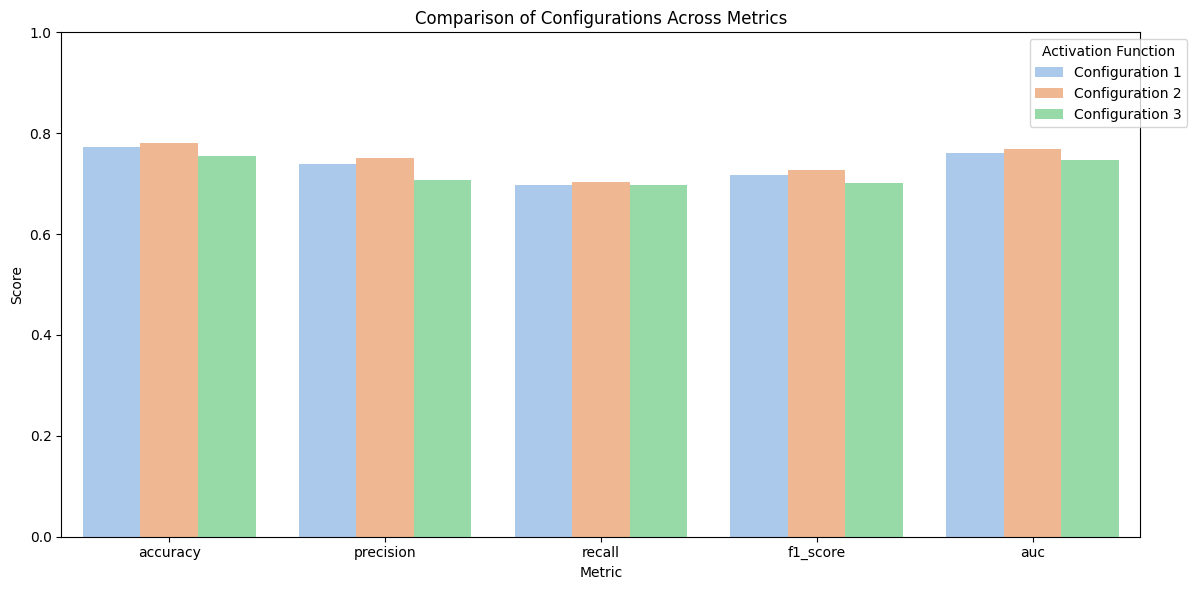

In [16]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_long,
    x="metric",
    y="value",
    hue="configuration",
    palette="pastel")


plt.title("Comparison of Configurations Across Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend(title="Activation Function", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

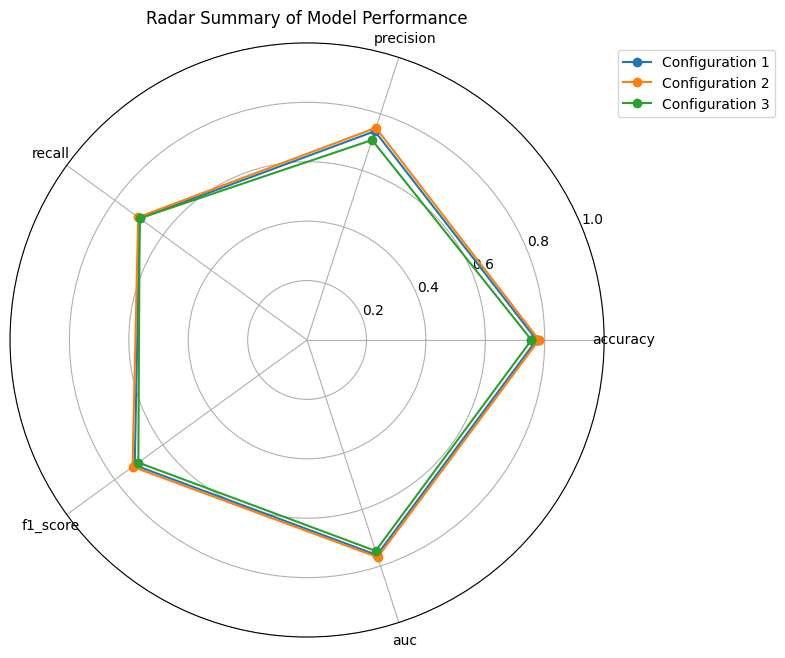

In [17]:


metrics = ["accuracy", "precision", "recall", "f1_score", "auc"]
labels = metrics
num_metrics = len(metrics)

angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8, 8))

for i in range(len(df)):
    values = df.loc[i, metrics].tolist()
    values += values[:1]
    
    plt.polar(angles, values, label=df.loc[i, "configuration"], marker='o')

plt.xticks(angles[:-1], labels)
plt.ylim(0, 1)
plt.title("Radar Summary of Model Performance")
plt.legend(bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()

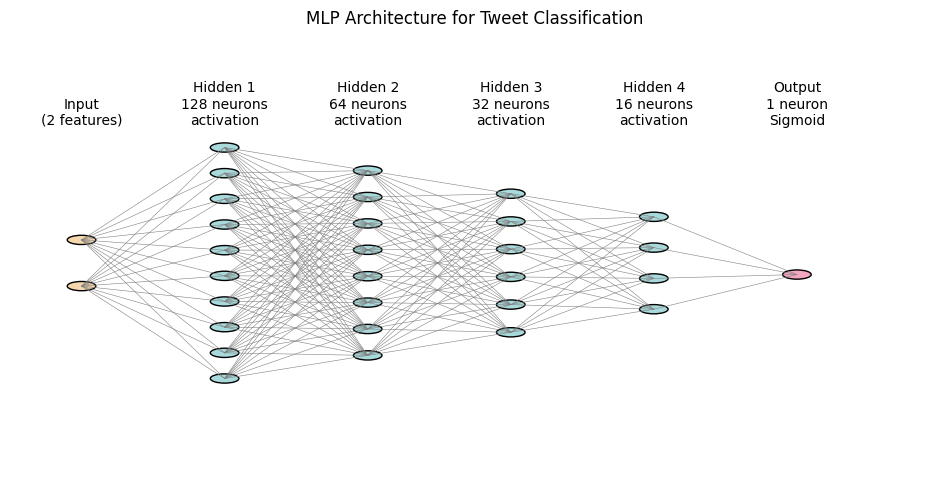

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def draw_mlp(input_neurons=2, activation_name="activation"):
    """
    Draws a visual representation of your MLP architecture:
    Input → 128 → 64 → 32 → 16 → 1 (Sigmoid)
    Neurons are visually compressed for clarity.
    """

    # Compressed visualization sizes (not literal neuron counts)
    layer_sizes = [input_neurons, 10, 8, 6, 4, 1]

    colors = [
        "#F6D6AD",  # Input
        "#A8DADC",  # Hidden
        "#A8DADC",
        "#A8DADC",
        "#A8DADC",
        "#F4A7C1"   # Output
    ]

    fig, ax = plt.subplots(figsize=(12,6))

    x_spacing = 2
    y_spacing = 1

    for layer_index, layer_size in enumerate(layer_sizes):
        x = layer_index * x_spacing
        y_positions = np.linspace(
            -layer_size / 2,
            layer_size / 2,
            layer_size
        )

        for y in y_positions:
            circle = plt.Circle((x, y), 0.2,
                                color=colors[layer_index],
                                ec="black")
            ax.add_patch(circle)

        # Connections
        if layer_index < len(layer_sizes) - 1:
            next_layer_size = layer_sizes[layer_index + 1]
            next_y_positions = np.linspace(
                -next_layer_size / 2,
                next_layer_size / 2,
                next_layer_size
            )

            for y1 in y_positions:
                for y2 in next_y_positions:
                    ax.plot(
                        [x, x + x_spacing],
                        [y1, y2],
                        color="gray",
                        linewidth=0.4
                    )

    # Correct labels for YOUR architecture
    layer_names = [
        f"Input\n({input_neurons} features)",
        f"Hidden 1\n128 neurons\n{activation_name}",
        f"Hidden 2\n64 neurons\n{activation_name}",
        f"Hidden 3\n32 neurons\n{activation_name}",
        f"Hidden 4\n16 neurons\n{activation_name}",
        "Output\n1 neuron\nSigmoid"
    ]

    for i, name in enumerate(layer_names):
        ax.text(i * x_spacing,
                max(layer_sizes)/2 + 1,
                name,
                ha='center')

    ax.set_xlim(-1, x_spacing * (len(layer_sizes)))
    ax.set_ylim(-max(layer_sizes), max(layer_sizes))
    ax.axis("off")

    plt.title("MLP Architecture for Tweet Classification")
    plt.show()

draw_mlp()

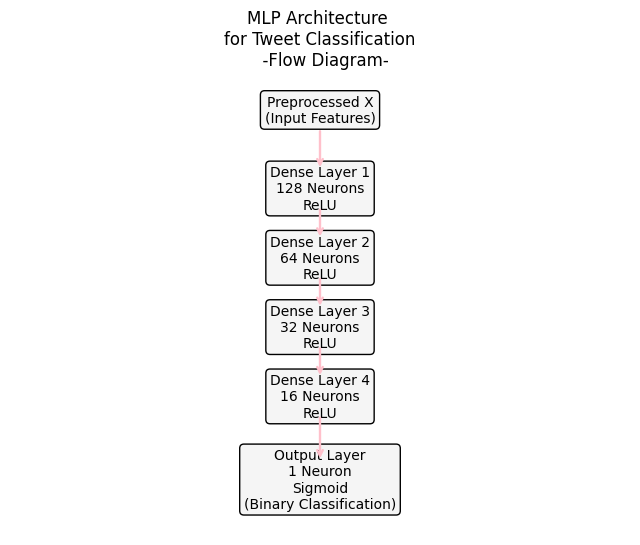

In [19]:


def draw_mlp_flow_correct():
    fig, ax = plt.subplots(figsize=(8,6))

    box_style = dict(
        boxstyle="round",
        edgecolor="black",
        facecolor="#F5F5F5"
    )

    # Positions (top to bottom)
    input_pos   = (0.5, 0.92)
    dense1_pos  = (0.5, 0.75)
    dense2_pos  = (0.5, 0.60)
    dense3_pos  = (0.5, 0.45)
    dense4_pos  = (0.5, 0.30)
    output_pos  = (0.5, 0.12)

    # Draw boxes first
    ax.text(*input_pos,
            "Preprocessed X\n(Input Features)",
            ha="center", va="center", bbox=box_style)

    ax.text(*dense1_pos,
            "Dense Layer 1\n128 Neurons\nReLU",
            ha="center", va="center", bbox=box_style)

    ax.text(*dense2_pos,
            "Dense Layer 2\n64 Neurons\nReLU",
            ha="center", va="center", bbox=box_style)
    
    ax.text(*dense3_pos,
            "Dense Layer 3\n32 Neurons\nReLU",
            ha="center", va="center", bbox=box_style)

    ax.text(*dense4_pos,
            "Dense Layer 4\n16 Neurons\nReLU",
            ha="center", va="center", bbox=box_style)

    ax.text(*output_pos,
            "Output Layer\n1 Neuron\nSigmoid\n(Binary Classification)",
            ha="center", va="center", bbox=box_style)

    
    arrow_style = dict(arrowstyle="->", linewidth=1.7, color="pink")

    offset = 0.04

    ax.annotate("", 
            xy=(dense1_pos[0], dense1_pos[1] + offset), 
            xytext=(input_pos[0], input_pos[1] - offset), 
            arrowprops=arrow_style)

    ax.annotate("", 
            xy=(dense2_pos[0], dense2_pos[1] + offset), 
            xytext=(dense1_pos[0], dense1_pos[1] - offset), 
            arrowprops=arrow_style)

    ax.annotate("", 
            xy=(dense3_pos[0], dense3_pos[1] + offset), 
            xytext=(dense2_pos[0], dense2_pos[1] - offset), 
            arrowprops=arrow_style)

    ax.annotate("", 
            xy=(dense4_pos[0], dense4_pos[1] + offset), 
            xytext=(dense3_pos[0], dense3_pos[1] - offset), 
            arrowprops=arrow_style)

    ax.annotate("", 
            xy=(output_pos[0], output_pos[1] + offset), 
            xytext=(dense4_pos[0], dense4_pos[1] - offset), 
            arrowprops=arrow_style)

    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.axis("off")

    plt.title("MLP Architecture \nfor Tweet Classification\n  -Flow Diagram-")
    plt.show()

draw_mlp_flow_correct()